# Zomato Bangalore Restaurant Market Analysis

**Objective:** Identify what drives customer satisfaction and restaurant success across Zomato-listed restaurants in Bangalore, and translate the findings into recommendations for restaurant owners, aggregator platforms, and investors.

**Dataset:** Zomato Bangalore restaurant listings (`zomato.csv`) — includes location, cuisine, cost, online ordering/table booking availability, votes, and customer rating for each listing.

**Scope note:** Each row represents a *listing*, not necessarily a unique physical restaurant — a single restaurant can appear multiple times under different `listed_in(type)` categories (e.g. once under "Delivery" and again under "Dine-out"). This is addressed explicitly in the Data Quality section below so that listing-level and restaurant-level metrics are not conflated.


## 1. Setup and Data Loading

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [15]:


df = pd.read_csv("https://media.githubusercontent.com/media/AkhilKataru/Restaurant_Rating_Drivers/refs/heads/main/zomato.csv")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [16]:
print("Rows, columns:", df.shape)
df.info()

Rows, columns: (51717, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  revi

## 2. Data Cleaning

The raw export has several issues that need to be resolved before analysis:
- Column names contain brackets/spaces (`approx_cost(for two people)`, `listed_in(type)`) — renamed for usability.
- `rate` is stored as text (e.g. `"4.1/5"`, `"NEW"`, `"-"`) — parsed into a numeric `rating` column.
- `approx_cost(for two people)` contains thousand separators (e.g. `"1,200"`) — cleaned and converted to numeric.
- `online_order` / `book_table` are stored as Yes/No — mapped to 1/0 for aggregation.
- `cuisines` and `rest_type` can contain multiple comma-separated values per row — the first (primary) value is extracted into `main_cuisine` / `main_rest_type` so each listing can be grouped by a single category.
- Columns not relevant to this analysis (`url`, `phone`, `menu_item`, `reviews_list`, `dish_liked`) are dropped.


In [17]:
df = df.drop(['url', 'phone', 'menu_item', 'reviews_list', 'dish_liked'], axis=1)

df = df.rename(columns={
    'approx_cost(for two people)': 'cost_for_two',
    'listed_in(type)': 'listed_type',
    'listed_in(city)': 'listed_city'
})
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'cost_for_two', 'listed_type',
       'listed_city'],
      dtype='object')

In [18]:
def clean_rate(value):
    """Convert '4.1/5' -> 4.1, and treat 'NEW' / '-' / nulls as missing."""
    if pd.isnull(value):
        return np.nan
    value = str(value)
    if value in ('NEW', '-'):
        return np.nan
    return float(value.split('/')[0])

df['rating'] = df['rate'].apply(clean_rate)
df = df.drop('rate', axis=1)
df[['name', 'rating']].head()

,name,rating
0,Jalsa,4.1
1,Spice Elephant,4.1
2,San Churro Cafe,3.8
3,Addhuri Udupi Bhojana,3.7
4,Grand Village,3.8


In [19]:
df['cost_for_two'] = df['cost_for_two'].astype(str).str.replace(',', '')
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors='coerce')

df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})
df['book_table'] = df['book_table'].map({'Yes': 1, 'No': 0})

df['cuisines'] = df['cuisines'].astype(str)
df['main_cuisine'] = df['cuisines'].apply(lambda x: x.split(',')[0].strip())

df['rest_type'] = df['rest_type'].astype(str)
df['main_rest_type'] = df['rest_type'].apply(lambda x: x.split(',')[0].strip())

df[['cost_for_two', 'online_order', 'book_table', 'main_cuisine', 'main_rest_type']].head()

,cost_for_two,online_order,book_table,main_cuisine,main_rest_type
0,800.0,1,1,North Indian,Casual Dining
1,800.0,1,0,Chinese,Casual Dining
2,800.0,1,0,Cafe,Cafe
3,300.0,0,0,South Indian,Quick Bites
4,600.0,0,0,North Indian,Casual Dining


In [20]:
print("Before removing exact duplicate rows:", df.shape)
df = df.drop_duplicates()
print("After removing exact duplicate rows:", df.shape)

# Rating should only fall between 1 and 5; drop anything outside that range
# (keep nulls, which are handled separately wherever rating is used).
df = df[((df['rating'] >= 1) & (df['rating'] <= 5)) | (df['rating'].isnull())]
df.shape

Before removing exact duplicate rows: (51717, 14)
After removing exact duplicate rows: (51632, 14)


(51632, 14)

### Restaurant-level vs. listing-level duplication

The same physical restaurant can appear multiple times in this dataset under different `listed_type` categories. Counting every row as a distinct restaurant would inflate location and cuisine counts. The cell below quantifies how common this is, so downstream metrics are described accurately as *listings* rather than *unique restaurants*.


In [21]:
duplicate_listings = df.duplicated(subset=['name', 'address']).sum()
pct_duplicate = round(duplicate_listings / len(df) * 100, 2)
unique_restaurants = df.drop_duplicates(subset=['name', 'address']).shape[0]

print(f"Total listings: {len(df):,}")
print(f"Rows sharing name + address with another row: {duplicate_listings:,} ({pct_duplicate}% of listings)")
print(f"Estimated unique physical restaurants: {unique_restaurants:,}")

Total listings: 51,632
Rows sharing name + address with another row: 39,133 (75.79% of listings)
Estimated unique physical restaurants: 12,499


## 3. Data Quality Summary

In [22]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_pct[missing_pct > 0].sort_values(ascending=False)

,0
rating,19.43
cost_for_two,0.67
location,0.04


`rating` is the only column with meaningful missingness — largely newly listed restaurants that have not yet accumulated reviews. These are excluded (via `.dropna()`) from any rating-based calculation rather than imputed, since filling in an assumed rating would distort the true distribution and misrepresent restaurant quality.


In [23]:
df.describe()

,online_order,book_table,votes,cost_for_two,rating
count,51632.000000,51632.000000,51632.000000,51288.000000,41602.000000
mean,0.588375,0.124341,283.159901,555.075749,3.700082
std,0.492133,0.329974,803.125144,438.528585,0.440417
min,0.000000,0.000000,0.000000,40.000000,1.800000
25%,0.000000,0.000000,7.000000,300.000000,3.400000
50%,1.000000,0.000000,41.000000,400.000000,3.700000
75%,1.000000,0.000000,198.000000,650.000000,4.000000
max,1.000000,1.000000,16832.000000,6000.000000,4.900000


In [24]:
# Cost for two has a long right tail (a small number of very high-end restaurants).
# Capping at the 99th percentile prevents these outliers from distorting the
# cost distribution and cost-vs-rating comparisons below.
cap_value = df['cost_for_two'].quantile(0.99)
df['cost_for_two'] = df['cost_for_two'].clip(upper=cap_value)
print(f"cost_for_two capped at the 99th percentile: {cap_value:.0f}")

cost_for_two capped at the 99th percentile: 2200


## 4. Helper Functions

The comparisons below share the same two patterns — a two-group rating comparison, and a "top N by count" breakdown — so each is defined once and reused instead of repeating similar plotting code.


In [25]:
def compare_rating_by_group(df, group_col, group_labels, title):
    """Boxplot + t-test comparing 'rating' between a binary group column's two values."""
    plt.figure(figsize=(6, 5))
    sns.boxplot(x=group_col, y='rating', data=df)
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel('Rating')
    plt.xticks([0, 1], group_labels)
    plt.savefig(f'images/rating_by_{group_col}.png', dpi=150, bbox_inches='tight')
    plt.show()

    group_1 = df.loc[df[group_col] == 1, 'rating'].dropna()
    group_0 = df.loc[df[group_col] == 0, 'rating'].dropna()

    print(f"Average rating ({group_labels[1]}): {group_1.mean():.2f}")
    print(f"Average rating ({group_labels[0]}): {group_0.mean():.2f}")
    print(f"Difference: {group_1.mean() - group_0.mean():.2f}")



def plot_top_n(series, n, title, xlabel, ylabel):
    """Horizontal bar chart of the top N most frequent values in a categorical series."""
    top_n = series.value_counts().head(n)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_n.values, y=top_n.index)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.savefig(f'images/{title}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return top_n

## 5. Exploratory Analysis

### Rating Distribution

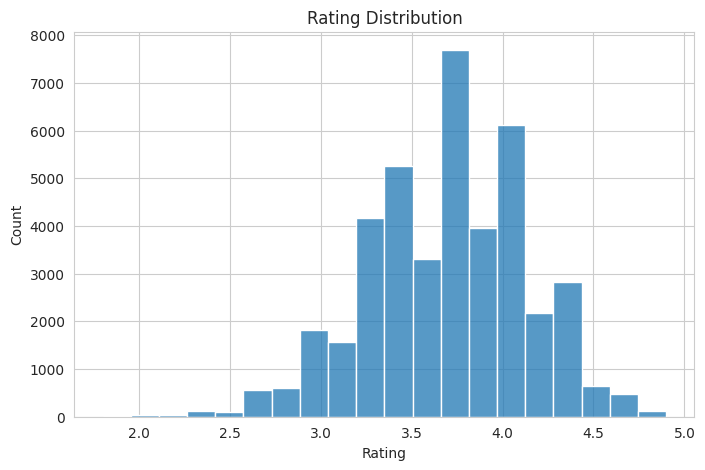

Average rating: 3.7
Median rating: 3.7


In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(df['rating'].dropna(), bins=20)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig(f'images/Rating Distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Average rating:", round(df['rating'].mean(), 2))
print("Median rating:", round(df['rating'].median(), 2))

Most listings fall between 3.3 and 4.2. Ratings below 2.5 or above 4.5 are uncommon, indicating rating scores cluster tightly around the mean rather than spreading across the full 1–5 range.

### Online Ordering and Table Booking vs. Rating

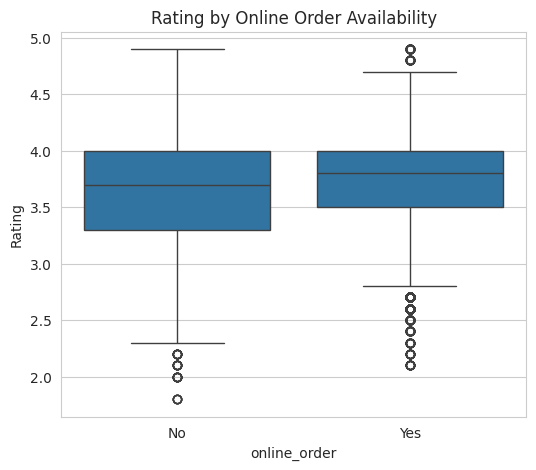

Average rating (Yes): 3.72
Average rating (No): 3.66
Difference: 0.06


In [27]:
compare_rating_by_group(df, 'online_order', ['No', 'Yes'], 'Rating by Online Order Availability')

Restaurants offering online ordering show a modestly higher average rating. Given the large sample size, statistical significance alone does not imply the effect is operationally large — the practical gap is small.

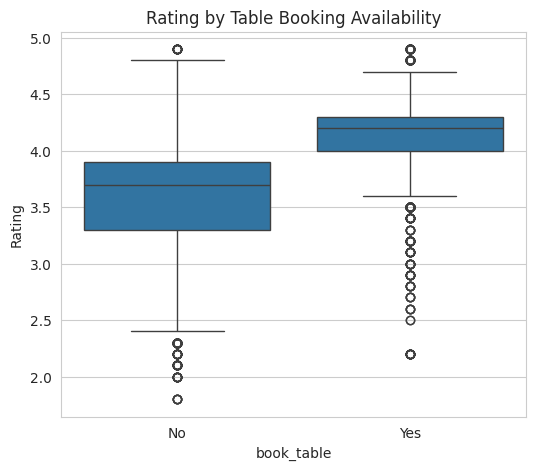

Average rating (Yes): 4.14
Average rating (No): 3.62
Difference: 0.52


In [28]:
compare_rating_by_group(df, 'book_table', ['No', 'Yes'], 'Rating by Table Booking Availability')

Table booking availability shows the largest rating gap identified in this analysis. This plausibly reflects the operational maturity typically associated with restaurants that support reservations, rather than table booking itself causing higher ratings.

### Restaurant Landscape: Locations, Cuisines, and Types

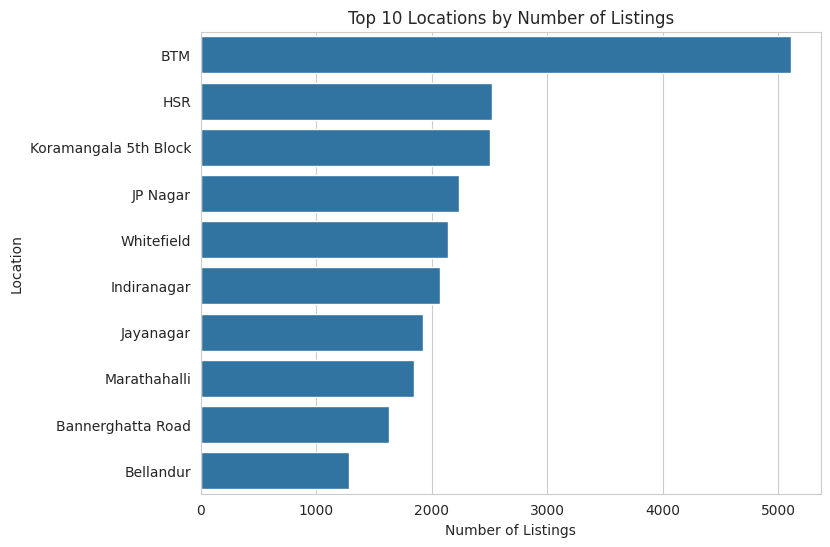

,count
location,
BTM,5114
HSR,2521
Koramangala 5th Block,2502
JP Nagar,2234
Whitefield,2142
Indiranagar,2075
Jayanagar,1926
Marathahalli,1843
Bannerghatta Road,1630


In [29]:
top_locations = plot_top_n(df['location'], 10, 'Top 10 Locations by Number of Listings', 'Number of Listings', 'Location')
top_locations

BTM has the highest listing volume of any locality. This reflects listing density, not restaurant quality — that distinction is examined separately below.

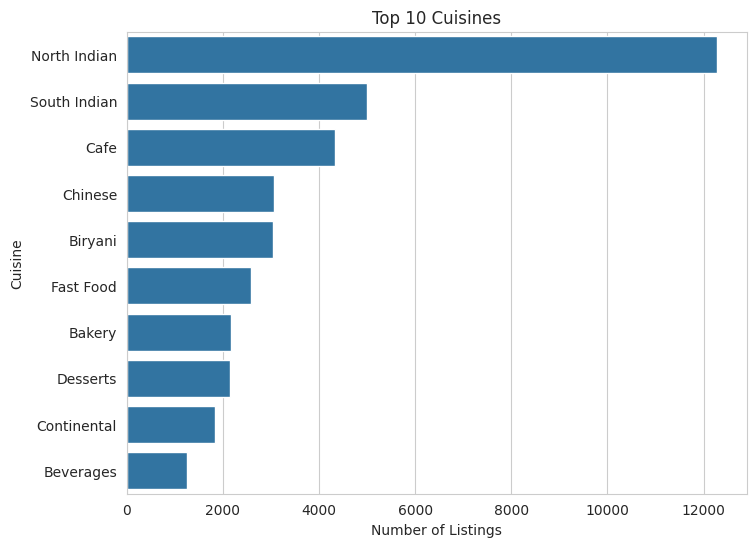

,count
main_cuisine,
North Indian,12284
South Indian,5005
Cafe,4325
Chinese,3058
Biryani,3049
Fast Food,2588
Bakery,2174
Desserts,2146
Continental,1836


In [30]:
top_cuisines = plot_top_n(df['main_cuisine'], 10, 'Top 10 Cuisines', 'Number of Listings', 'Cuisine')
top_cuisines

North Indian is the most common primary cuisine among Bangalore listings.

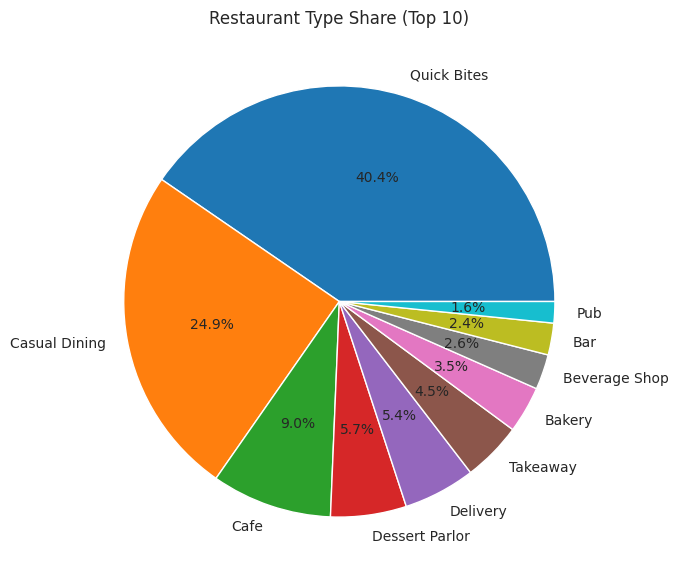

,count
main_rest_type,
Quick Bites,19497
Casual Dining,12003
Cafe,4358
Dessert Parlor,2741
Delivery,2600
Takeaway,2151
Bakery,1688
Beverage Shop,1271
Bar,1150


In [31]:
top_types = df['main_rest_type'].value_counts().head(10)

plt.figure(figsize=(7, 7))
plt.pie(top_types.values, labels=top_types.index, autopct='%1.1f%%')
plt.title('Restaurant Type Share (Top 10)')
plt.savefig(f'images/Restaurant Type Share (Top 10).png', dpi=150, bbox_inches='tight')
plt.show()

top_types

Quick Bites is the dominant restaurant type, consistent with Bangalore's high density of casual, fast-service dining formats.

### Cost Analysis

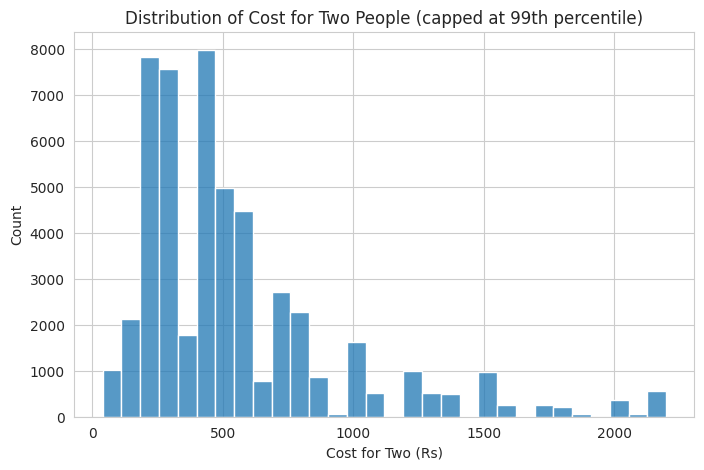

Average cost for two: 548.49
Median cost for two: 400.0


In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(df['cost_for_two'].dropna(), bins=30)
plt.title('Distribution of Cost for Two People (capped at 99th percentile)')
plt.xlabel('Cost for Two (Rs)')
plt.savefig(f'images/Distribution of Cost for Two People.png', dpi=150, bbox_inches='tight')
plt.show()

print("Average cost for two:", round(df['cost_for_two'].mean(), 2))
print("Median cost for two:", round(df['cost_for_two'].median(), 2))

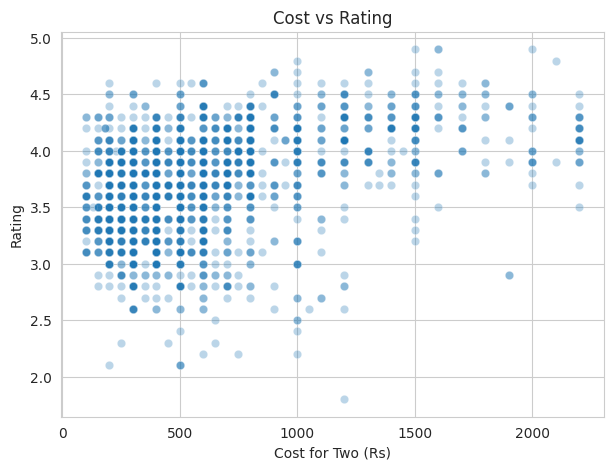

Correlation between cost and rating: 0.398


In [33]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='cost_for_two', y='rating', data=df.sample(3000, random_state=1), alpha=0.3)
plt.title('Cost vs Rating')
plt.xlabel('Cost for Two (Rs)')
plt.ylabel('Rating')
plt.show()

corr_cost_rating = df['cost_for_two'].corr(df['rating'])
print("Correlation between cost and rating:", round(corr_cost_rating, 3))

Cost shows only a weak positive correlation with rating — higher-priced restaurants are not meaningfully more likely to be rated well.

### Popularity (Votes) vs. Rating

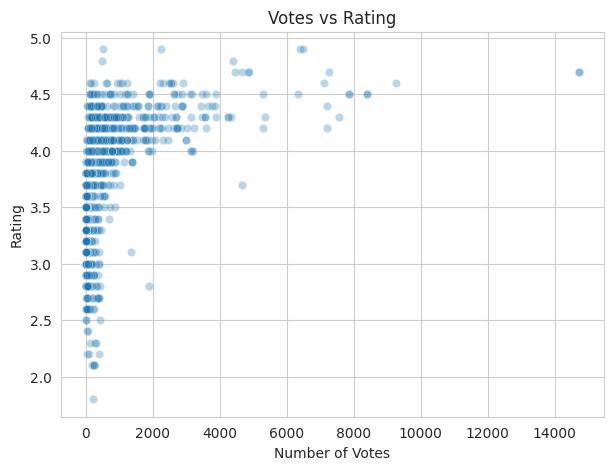

Correlation between votes and rating: 0.434


In [34]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='votes', y='rating', data=df.sample(3000, random_state=1), alpha=0.3)
plt.title('Votes vs Rating')
plt.xlabel('Number of Votes')
plt.ylabel('Rating')
plt.show()

corr_votes_rating = df['votes'].corr(df['rating'])
print("Correlation between votes and rating:", round(corr_votes_rating, 3))

Votes correlate with rating more strongly than cost does, suggesting that popularity (as a proxy for repeat customer engagement) is a more reliable quality signal than price.

### Highest-Rated Locations

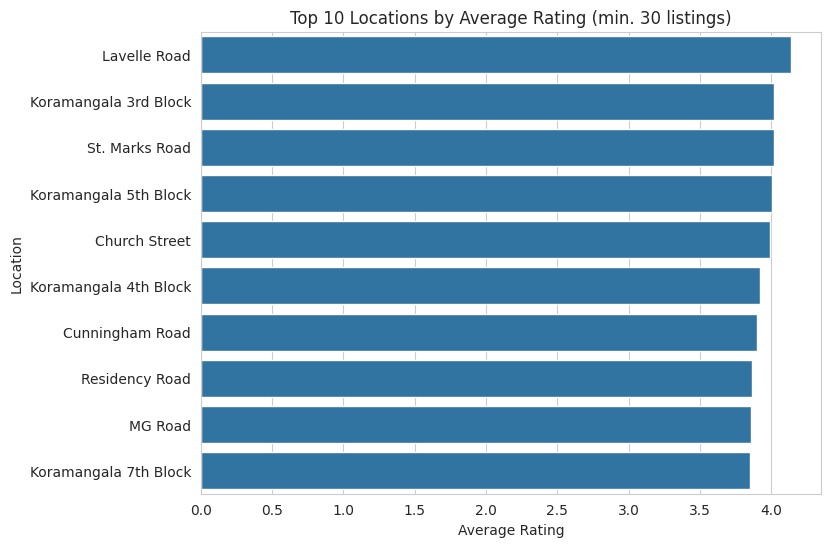

,mean,count
location,,
Lavelle Road,4.140871,482
Koramangala 3rd Block,4.020526,190
St. Marks Road,4.017201,343
Koramangala 5th Block,4.005870,2317
Church Street,3.990976,543
Koramangala 4th Block,3.918668,841
Cunningham Road,3.900633,474
Residency Road,3.861960,602
MG Road,3.855185,810


In [35]:
location_rating = df.groupby('location')['rating'].agg(['mean', 'count'])
location_rating = location_rating[location_rating['count'] >= 30]
location_rating = location_rating.sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=location_rating['mean'], y=location_rating.index)
plt.title('Top 10 Locations by Average Rating (min. 30 listings)')
plt.xlabel('Average Rating')
plt.ylabel('Location')
plt.show()

location_rating

This ranking differs materially from the listing-count ranking above — the localities with the most restaurants are not the same ones with the highest average ratings, indicating listing density and listing quality are independent dimensions of this market.

### Correlation Overview

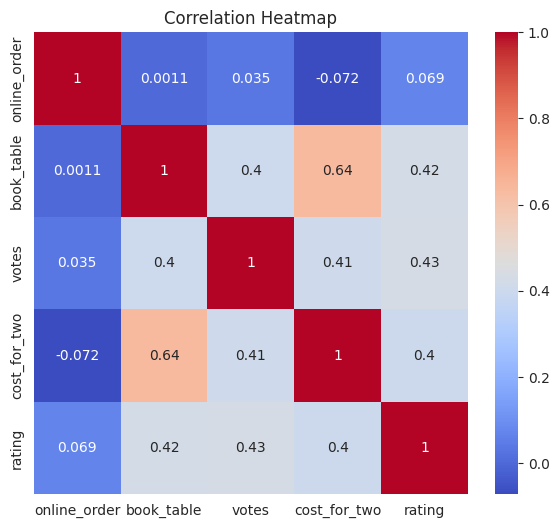

In [36]:
num_cols = ['online_order', 'book_table', 'votes', 'cost_for_two', 'rating']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig(f'images/Correlation Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Votes has the strongest relationship with rating among the numeric variables considered, followed by cost. Online ordering and table booking show smaller, positive associations.

## 6. Business Recommendations

**For Restaurant Owners**
1. Enable table reservations where feasible — this shows the strongest association with higher ratings in this dataset, likely reflecting the operational maturity and service quality that customers reward.
2. Treat online ordering as a baseline requirement rather than a differentiator — competitive advantage needs to come from food quality and service, not order channel alone.
3. Offer a focused cuisine range rather than an overly narrow or overly broad menu, in line with the patterns observed in higher-rated listings.
4. Evaluate expansion into under-served, high-rated localities rather than the most saturated hubs such as BTM.

**For Zomato / Aggregator Platforms**
1. Use vote count as a leading indicator of quality for ranking, since it correlates more strongly with rating than price.
2. Introduce a "new / low-review" confidence flag for listings with very few votes, where rating volatility is high, to avoid misleading users.
3. Support restaurants in saturated localities with differentiation tools (cuisine tagging, promotions), since listing density alone does not guarantee customer satisfaction.

**For Investors**
1. Favor locations and formats with structurally higher ratings (e.g. table-booking-enabled casual/fine dining in high-rated micro-markets) over the most saturated quick-bite segments, which face intense price competition.


## 7. Key Takeaways

1. Ratings are concentrated between 3.3 and 4.2, with few listings at either extreme.
2. Table booking availability shows the largest rating gap of any variable examined
3. Online ordering has a small, statistically measurable positive association with rating.
4. BTM leads in listing volume but not in average rating — listing density and listing quality are distinct.
5. North Indian is the most common cuisine; Quick Bites is the most common restaurant type.
6. Votes correlate with rating more strongly than cost does, indicating popularity is a more reliable quality signal than price.


**Methodology notes:** listing-level duplication was quantified explicitly rather than assumed away; cost outliers were capped at the 99th percentile before distributional analysis;
